In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import anndata as ad
from adjustText import adjust_text

from cellassign import assign_cats

from cellbender.remove_background.downstream import load_anndata_from_input_and_output as load_anndata_cellbender

import cellrank as cr
from cellrank.estimators import GPCCA

import doubletdetection

from fa2 import ForceAtlas2

import gc

import harmonypy as hm

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

import networkx as nx

import numpy as np

import palantir

import pandas as pd

import phate

import plotly.express as px

from pybiomart import Server

import re 

from rpy2.robjects import globalenv
from rpy2.robjects import pandas2ri

import scanpy as sc
import scanpy.external as sce

import scFates as scf

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

import scipy.sparse as sp
from scipy.sparse import csr_matrix, issparse

import scvelo as scv

import seaborn as sns

from sklearn.decomposition import PCA

import triku as tk

In [ ]:
from pyfuncs.dropletQC import classify_empty_and_damaged
from pyfuncs.general import preprocessing_adata_sub, set_plotting_style, plot_volcano
from pyfuncs.general import magma
set_plotting_style()

In [ ]:
palette = {
    # ---- Major (igual que antes) ----
    'Endothelial': "#E766E7",
    'FAP':         "#165A81",
    'Immune':      "#6933AF",
    'Kranocyte':   "#C23C64",
    'Satellite':   "#289C79",
    'Tenocyte':    "#D38E28",

    # ---- Minor (más oscuros) ----
    # FAP (7)
    'FAP_A':"#C7CDD3",
    'FAP_AB':"#899199",
    'FAP_AF':"#565D63",

    'FAP_B1':"#6E61BB",
    'FAP_B2':"#3C2F88",

    'FAP_C' :"#6BB6D3",
    'FAP_D' :"#3C85A2",
    'FAP_E' :"#175274",
    'FAP_F' :"#05293C",

    # Tenocyte (4)
    'Teno_A':"#EABD62",
    'Teno_B':"#C6993A",
    'Teno_C':"#6F5214",
    'Teno_D':"#392705",

    # Kranocyte (3)
    'Krano_A':"#E46283",
    'Krano_B':"#9C2B60",
    'Krano_C':"#550D29",

    # Satellite (3)
    'Sat_A1':"#67DAB7",
    'Sat_A2':"#2E9B76",
    'Sat_B' :"#084233",
}

In [ ]:
seed = 0

In [ ]:
# Alevin outputs Ensembl IDs, and we will transform those to Gene symbols
server = Server(host='http://www.ensembl.org')

df = server.marts['ENSEMBL_MART_ENSEMBL'].datasets['mmusculus_gene_ensembl'].query(attributes=['ensembl_gene_id', 'external_gene_name'])
dict_ensemble_gene = dict(zip(df['Gene stable ID'], df['Gene name']))

# Data loading and QC

In [ ]:
def load_mtx(mtx_path, barcodes_path, varnames_path):
    """
    Load a matrix from a .mtx file and its associated barcodes and variable names.
    """
    adata = sc.read_mtx(mtx_path).T
    adata_barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')
    adata_varnames = pd.read_csv(varnames_path, header=None, sep='\t')
    
    adata.var_names = adata_varnames[0].values
    adata.obs_names = adata_barcodes[0].values
    
    return adata

In [ ]:
def load_full_adata(STARsolo_path, raw_counts=True, include_cellbender=True, load_velocyto=True):

    if raw_counts:
        dirsub = 'raw'
    else:
        dirsub = 'filtered'

    if include_cellbender: # This should be run on a second pass, the first pass should be false
        adata = load_anndata_cellbender(
                    input_file=f'{STARsolo_path}/adata_raw.h5ad',
                    output_file=f'{STARsolo_path}/CellBender/adata_raw_cellbender.h5',
                    input_layer_key='raw_counts',  # this will be the raw data layer
                )
        
        adata.raw = adata
    else:
        adata = load_mtx(f'{STARsolo_path}/GeneFull/{dirsub}/UniqueAndMult-EM.mtx', f'{STARsolo_path}/GeneFull/{dirsub}/barcodes.tsv', f'{STARsolo_path}/GeneFull/{dirsub}/features.tsv')
        adata.layers['raw_counts'] = adata.X.copy()

    if load_velocyto:
        adata_velocyto_spliced = load_mtx(f'{STARsolo_path}/Velocyto/{dirsub}/spliced.mtx', f'{STARsolo_path}/Velocyto/{dirsub}/barcodes.tsv', f'{STARsolo_path}/Velocyto/{dirsub}/features.tsv')
        adata_velocyto_unspliced = load_mtx(f'{STARsolo_path}/Velocyto/{dirsub}/unspliced.mtx', f'{STARsolo_path}/Velocyto/{dirsub}/barcodes.tsv', f'{STARsolo_path}/Velocyto/{dirsub}/features.tsv')
        adata_velocyto_ambiguous = load_mtx(f'{STARsolo_path}/Velocyto/{dirsub}/ambiguous.mtx', f'{STARsolo_path}/Velocyto/{dirsub}/barcodes.tsv', f'{STARsolo_path}/Velocyto/{dirsub}/features.tsv')

        adata.layers['spliced'] = adata_velocyto_spliced[adata.obs_names, adata.var_names].X.copy()
        adata.layers['unspliced'] = adata_velocyto_unspliced[adata.obs_names, adata.var_names].X.copy()
        adata.layers['ambiguous'] = adata_velocyto_ambiguous[adata.obs_names, adata.var_names].X.copy()

        del adata_velocyto_spliced, adata_velocyto_unspliced, adata_velocyto_ambiguous
    
    adata.var_names_make_unique()

    return adata

In [ ]:
adata_AZ7845 = load_full_adata('data/ARAUZO_03/results_STAR/AZ7845/Solo.out', include_cellbender=False, load_velocyto=False)

In [ ]:
adata_AZ7846 = load_full_adata('data/ARAUZO_03/results_STAR/AZ7846/Solo.out', include_cellbender=False, load_velocyto=False)

## CellBender (remove ambient RNA)

In [ ]:
adata_AZ7845.write_h5ad('data/ARAUZO_03/results_STAR/AZ7845/Solo.out/adata_raw.h5ad')

In [ ]:
%%script False
!docker run --gpus all --rm -v /mnt/data:/mnt/data \
  us.gcr.io/broad-dsde-methods/cellbender:0.3.2 \
  cellbender remove-background \
    --input /mnt/data/Proyectos/kranocito/data/ARAUZO_03/results_STAR/AZ7845/Solo.out/adata_raw.h5ad \
    --output /mnt/data/Proyectos/kranocito/data/ARAUZO_03/results_STAR/AZ7845/Solo.out/CellBender/adata_raw_cellbender.h5 \
    --cuda

In [ ]:
adata_AZ7846.write_h5ad('data/ARAUZO_03/results_STAR/AZ7846/Solo.out/adata_raw.h5ad')

In [ ]:
%%script False
!docker run --gpus all --rm -v /mnt/data:/mnt/data \
  us.gcr.io/broad-dsde-methods/cellbender:0.3.2 \
  cellbender remove-background \
    --input /mnt/data/Proyectos/kranocito/data/ARAUZO_03/results_STAR/AZ7846/Solo.out/adata_raw.h5ad \
    --output /mnt/data/Proyectos/kranocito/data/ARAUZO_03/results_STAR/AZ7846/Solo.out/CellBender/adata_raw_cellbender.h5 \
    --cuda

In [ ]:
adata_AZ7845 = load_full_adata('data/ARAUZO_03/results_STAR/AZ7845/Solo.out', include_cellbender=True)

In [ ]:
adata_AZ7845

In [ ]:
adata_AZ7846 = load_full_adata('data/ARAUZO_03/results_STAR/AZ7846/Solo.out', include_cellbender=True)

In [ ]:
adata_AZ7846

In [ ]:
adata_AZ7845.obs

In [ ]:
def plot_cell_stats(adata):
    # Show cell 10X plot (it'll be truncated, but its good enough) and relationship between this and cell probabilities
    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    gene_counts = np.sort(adata.obs['n_cellbender'])[::-1]
    axs[0].plot(np.log10(np.arange(adata.shape[0]) + 1), np.log10(gene_counts + 1))

    gene_counts_filter = gene_counts[gene_counts > 200]
    axs[0].plot(np.log10(np.arange(len(gene_counts_filter)) + 1), np.log10(gene_counts_filter + 1))
    axs[0].set_xlabel('Cell rank')
    axs[0].set_ylabel('CellBender counts (log1p)')

    axs[1].scatter(adata.obs['cell_probability'], np.log10(adata.obs['n_cellbender'] + 1), s=2)
    axs[1].set_xlabel('Cell probability')
    axs[1].set_ylabel('CellBender counts (log1p)')

    axs[2].scatter(np.log10(adata.obs['n_cellbender'] + 1), np.log10(adata.obs['n_raw_counts'] + 1), s=2)
    axs[2].plot([0, 5], [0, 5], c='#bc0000')
    axs[2].set_xlabel('CellBender counts (cells)')
    axs[2].set_ylabel('Raw counts (cells)')


    plt.tight_layout()

def plot_gene_stats(adata):
    # Show ambient gene expression
    display(adata.var.sort_values(by='ambient_expression', ascending=False).head(15))

    fig, axs = plt.subplots(1, 3, figsize=(15,5))


    axs[0].scatter(np.log10(adata.var['n_cellbender'] + 1), adata.var['ambient_expression'], s=2)
    axs[0].set_xlabel('CellBender counts (genes)')
    axs[0].set_ylabel('Raw counts (log1p)')

    axs[1].scatter(np.log10(adata.var['n_cellbender'] + 1), (adata.var['n_cellbender'] + 1) / (adata.var['n_raw_counts'] + 1),  s=2)
    axs[1].set_xlabel('CellBender counts (genes)')
    axs[1].set_ylabel('$\\frac{\\text{CellBender counts  + 1}}{\\text{Raw counts + 1}}$ (genes)')

    axs[2].scatter(np.log10(adata.var['n_cellbender'] + 1), np.log10(adata.var['n_raw_counts'] + 1), s=2)
    axs[2].plot([0, 6], [0, 6], c='#bc0000')
    axs[2].set_xlabel('CellBender counts (genes)')
    axs[2].set_ylabel('Raw counts (genes)')
    plt.tight_layout()


In [ ]:
plot_cell_stats(adata_AZ7845)
plot_gene_stats(adata_AZ7845)


In [ ]:
plot_cell_stats(adata_AZ7846)
plot_gene_stats(adata_AZ7846)

In [ ]:
sc.pp.filter_cells(adata_AZ7845, min_counts=200)
sc.pp.filter_cells(adata_AZ7846, min_counts=200)

In [ ]:
adata = sc.AnnData.concatenate(adata_AZ7845, adata_AZ7846, batch_key='batch', batch_categories=['AZ7845', 'AZ7846'])

In [ ]:
(adata.layers['unspliced'].sum() + adata.layers['spliced'].sum() + adata.layers['ambiguous'].sum()) / (adata.layers['raw_counts'].sum())

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20, )

In [ ]:
del adata_AZ7845, adata_AZ7846
gc.collect()

## QC - mt and raw reads

In [ ]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=True, inplace=True)

In [ ]:
sc.pl.violin(adata, ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='log1p_total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='log1p_total_counts', y='log1p_n_genes_by_counts')
sc.pl.scatter(adata, x='log1p_total_counts', y='cell_probability')

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
df = pd.DataFrame({'x': adata.obs['batch'], 'y': adata.obs['log1p_n_genes_by_counts'], 'y2': adata.obs['pct_counts_mt']})
sns.violinplot(x='x', y='y', data=df, ax=axs[0])
sns.violinplot(x='x', y='y2', data=df, ax=axs[1])

In [ ]:
adata.obs['lowQC_gene_counts'] = 0
adata.obs['lowQC_mt_pct'] = 0

adata.obs.loc[adata.obs['log1p_n_genes_by_counts'] < 6, 'lowQC_gene_counts'] = 1
adata.obs.loc[adata.obs['pct_counts_mt'] > 10, 'lowQC_mt_pct'] = 1

adata.obs['lowQC_gene_mt'] = adata.obs['lowQC_gene_counts'] * adata.obs['lowQC_mt_pct']

In [ ]:
adata.obs[['lowQC_gene_counts', 'lowQC_mt_pct', 'lowQC_mt_pct']].sum()

## QC - DropletQC [original workflow]

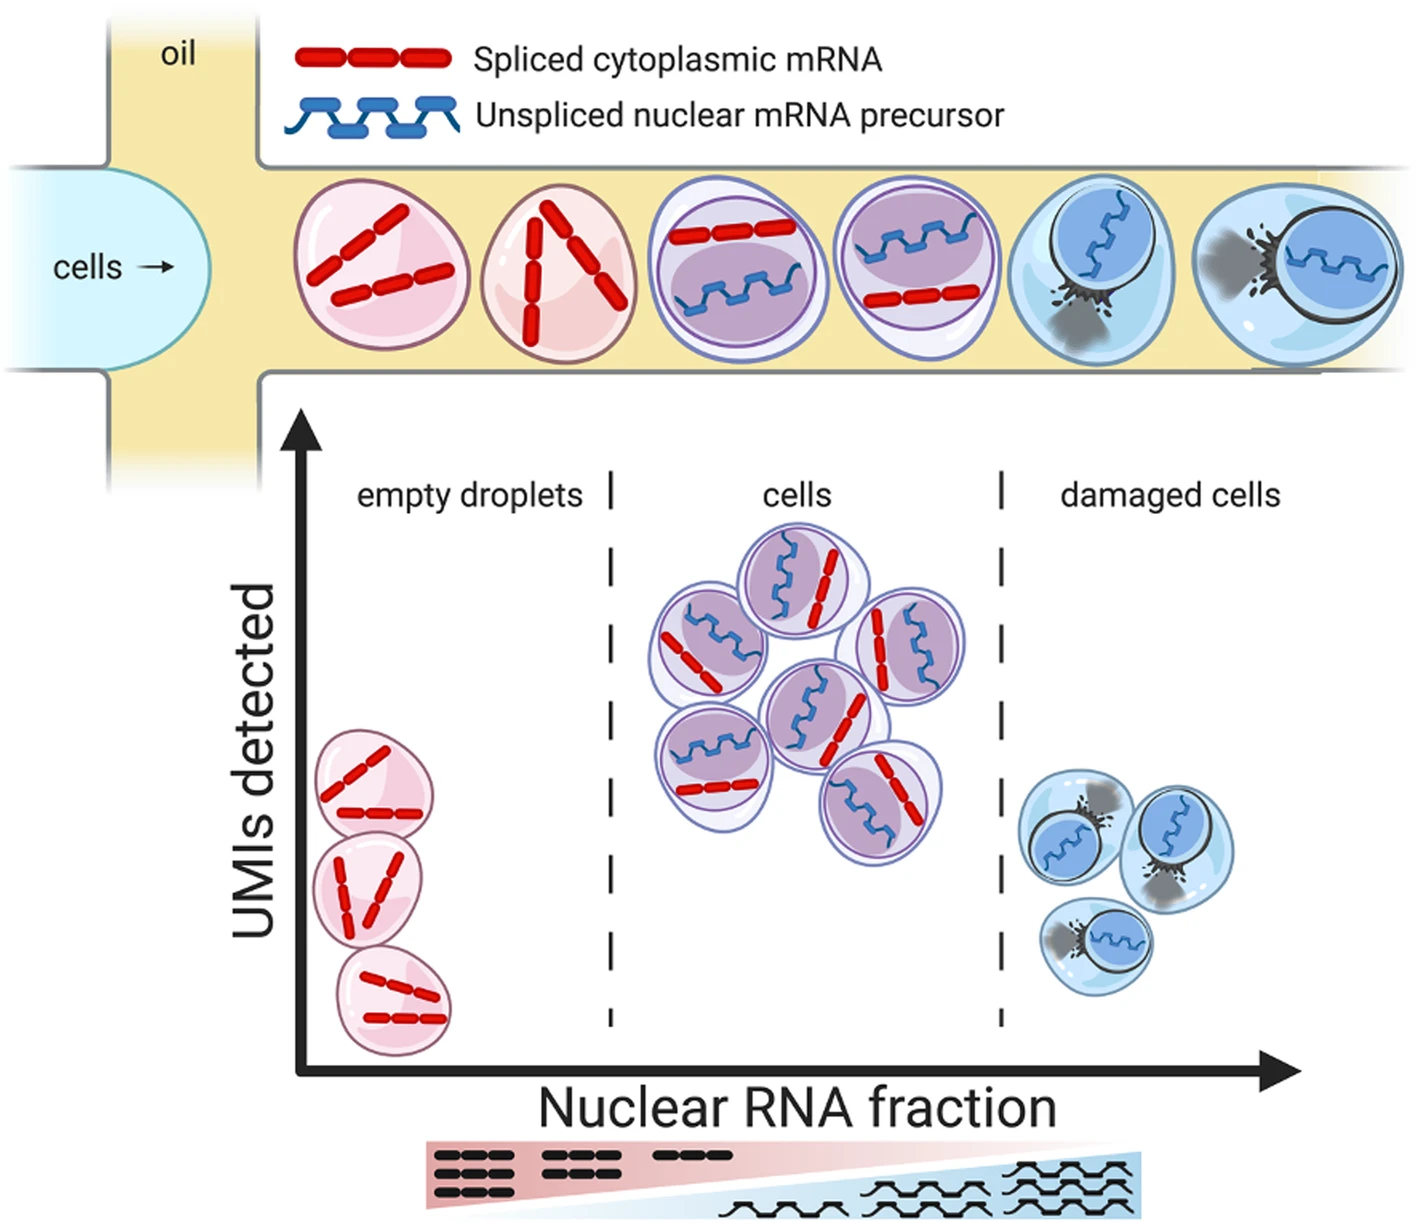

In [ ]:
%load_ext rpy2.ipython

In [ ]:
adata.obs['n_spliced'] = adata.layers['spliced'].sum(axis=1).A1
adata.obs['n_unspliced'] = adata.layers['unspliced'].sum(axis=1).A1
adata.obs['n_ambiguous'] = adata.layers['ambiguous'].sum(axis=1).A1

adata.obs['nuclear_RNA_frac'] = adata.obs['n_unspliced'] / (adata.obs['n_spliced'] + adata.obs['n_unspliced'])

In [ ]:
adata.obs['n_spliced_log1p'] = np.log1p(adata.obs['n_spliced'])
adata.obs['n_unspliced_log1p'] = np.log1p(adata.obs['n_unspliced'])
adata.obs['n_ambiguous_log1p'] = np.log1p(adata.obs['n_ambiguous'])
adata.obs['n_cellbender_log1p'] = np.log1p(adata.obs['n_cellbender'])

In [ ]:
nf_df = pd.DataFrame(adata.obs['nuclear_RNA_frac'])
nf = nf_df['nuclear_RNA_frac'].values
umi = np.asarray(adata.X.sum(axis=1)).ravel()

In [ ]:
%%R -i umi -i nf_df -o ed -o dc -o plots

library(DropletQC)

nf_umi <- data.frame(
  nf = nf_df$nuclear_RNA_frac,
  umi = umi
)
# 1) Etiquetas de empty droplets
ed <- identify_empty_drops(
  nf_umi = nf_umi,
  nf_rescue = 0.02,
  umi_rescue = 3000,
  include_plot = TRUE
)

if (!"cell_type" %in% colnames(ed)) ed$cell_type <- "all"

dc <- identify_damaged_cells(
  ed,
  verbose = FALSE,
  output_plots = TRUE
)

plots <- dc[[2]]  # NULL si output_plots=FALSE
# El dataframe final con 'cell_status' actualizado está en:
dc <- dc[[1]]

## QC - DropletQC [*improved* workflow]
The workflow from DropletQC failed in two parts:
- This clusters from empty droplets in not well partitioned -> we apply a KMeans clustering between the main cell cluster and a secondary cluster with low nuclear fraction
- It does not identify a damaged cell cluster, when its likely that one exists. To solve that I run a second clustering with either a GMM or a K-Means and ensure that the damaged cell cluster has at least > 0.4 of nuclear fraction compared to the main cluster. In that way I retrieve a better clustering solution.

In [ ]:
nf_df['umi'] = umi
nf_df['logumi'] = np.log10(umi + 1.0)

display(nf_df)

info = classify_empty_and_damaged(
    nf_df,
    method_cells="kmeans",          # o "gmm"
    nf_rescue=0.02, umi_rescue=3000,
    nf_damaged_threshold=0.5,
    random_state=0
)

info = classify_empty_and_damaged(
    nf_df,
    method_cells="gmm",          # o "gmm"
    nf_rescue=0.02, umi_rescue=3000,
    nf_damaged_threshold=0.5,
    random_state=0
)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.scatterplot(x='logumi', y='nuclear_RNA_frac', hue='classification_kmeans', data=nf_df, s=2, alpha=0.5, legend=None, ax=axs[0])
sns.scatterplot(x='logumi', y='nuclear_RNA_frac', hue='classification_gmm', data=nf_df, s=2, alpha=0.5, legend=None, ax=axs[1])

In [ ]:
adata.obs['QC_droplet'] = nf_df['classification_kmeans']

## QC - MALAT1 levels

In [ ]:
adata.obs['MALAT1'] = np.log1p(adata[:, 'Malat1'].X.todense().A1)

In [ ]:
sns.scatterplot(x='nuclear_RNA_frac', y='MALAT1', hue='QC_droplet', data=adata.obs, s=2, alpha=0.5)

In [ ]:
adata.obs['QC_low_MALAT1'] = 0
adata.obs.loc[(adata.obs['MALAT1'] < 2), 'QC_low_MALAT1'] = 1

In [ ]:
# Jaccard index for empty droplets and low MALAT1 levels
np.sum((adata.obs['QC_low_MALAT1'] == 1) * (adata.obs['QC_droplet'] == 'empty_droplet'))   / np.sum((adata.obs['QC_low_MALAT1'] == 1) + (adata.obs['QC_droplet'] == 'empty_droplet')) 

We see that all empty droplets have a low *Malat1* level, whereas cells with increased levels or normal levels are already detected as cell or damaged cell.

## Checking location of low QC cells

We are going to see where the marked flags are located. Supposedly, lowQC cells should create new cell types with with background gene expression. In that case, we are going to remove them to improve capability of doublet detection.

In [ ]:
# adata_all_cells = adata.copy()

In [ ]:
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15, )
sce.pp.harmony_integrate(adata_pp, 'batch', max_iter_harmony=20, random_state=seed)
sc.pp.neighbors(adata_pp, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.leiden(adata_pp, resolution=0.2, key_added="groups")
sc.tl.umap(adata_pp, min_dist=0.1, random_state=seed)

In [ ]:
sc.pl.umap(adata_pp, color=['batch', 'groups'])

In [ ]:
sc.pl.umap(adata_pp, color=['batch', 'groups', 
                            'log1p_n_genes_by_counts', 'pct_counts_mt', 
                            'lowQC_gene_counts', 'lowQC_mt_pct', 'lowQC_gene_mt',
                           'QC_low_MALAT1', 'nuclear_RNA_frac', 'QC_droplet', ])

In [ ]:
sc.tl.rank_genes_groups(adata_pp, 'groups', method='wilcoxon', key_added='rank_genes_groups_wilcoxon', 
                        use_raw=False)
sc.pl.rank_genes_groups_tracksplot(adata_pp, key='rank_genes_groups_wilcoxon', 
                                   n_genes=20, sharey=False, fontsize=12, dendrogram=False, 
                                   use_raw=False,)

We see that empry droplets, which correlate with low MALAT1, low count and high mitochondrial content cells, are gathered in a separate cell type with high expression of constitutive markers show in the figure of high expressed genes. This is expected: the genes that are going to be liberated to the empty droplet will more likely be the genes with higher expression. 

There is a second set of clusters with high nuclear fraction, labeleld as damaged cells. We are not going to remove these cells so far for two reasons: their DEGs are in line with DEGs expressed by other cells passing QC; and considering that this is a single-nuclei preparation, we do expect a higher set of cells with intronic content. We may remove these cell types afterwards if we see that they don't provide any useful information.

In [ ]:
adata = adata[(~ adata.obs['QC_droplet'].isin(['empty_droplet', 'damaged_cell'])) &  
              (adata.obs['lowQC_gene_counts'] == 0) & 
              (adata.obs['lowQC_mt_pct'] == 0), :].copy()

In [ ]:
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15, )
sce.pp.harmony_integrate(adata_pp, 'batch', max_iter_harmony=20, random_state=seed)
sc.pp.neighbors(adata_pp, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.leiden(adata_pp, resolution=0.5, key_added="groups")
sc.tl.umap(adata_pp, min_dist=0.2, random_state=seed)

In [ ]:
sc.pl.umap(adata_pp, color=['batch', 'groups', 
                            'log1p_n_genes_by_counts', 'pct_counts_mt', 
                            'lowQC_gene_counts', 'lowQC_mt_pct', 'lowQC_gene_mt',
                           'QC_low_MALAT1', 'nuclear_RNA_frac', 'QC_droplet', ])

In [ ]:
sc.pl.umap(adata_pp, color=['batch', 'groups'])

In [ ]:
# We are going to pass this initial clustering solution to the adata, for clustering purposes
adata.obs['groups'] = adata_pp.obs['groups'].copy()
adata.obsm['X_umap'] = adata_pp.obsm['X_umap'].copy()

In [ ]:
del adata_pp
gc.collect()

## Doublet flagging

To do this step we need some clusters. To do that we are going to run a basic clustering using harmony and then use the detected cell types as input of clusters

### DoubletDetection

In [ ]:
clf = doubletdetection.BoostClassifier(
    n_iters=10, 
    clustering_algorithm="louvain", 
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1,
)
doublets = clf.fit(adata.X).predict(p_thresh=1e-16, voter_thresh=0.5)
doublet_score = clf.doublet_score()


In [ ]:
clf.doublet_score().data

In [ ]:
adata.obs['DoubletDetection_score'] = doublet_score.data
adata.obs['DoubletDetection_mask'] = doublet_score.mask

In [ ]:
f = doubletdetection.plot.convergence(clf, show=True, p_thresh=1e-16, voter_thresh=0.5)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.scatterplot(x='log1p_n_genes_by_counts', y='nuclear_RNA_frac', hue='DoubletDetection_mask', data=adata.obs, s=2, alpha=0.5, ax=axs[0])
sns.scatterplot(x='log1p_n_genes_by_counts', y='nuclear_RNA_frac', hue='DoubletDetection_score', data=adata.obs, s=2, alpha=0.5, ax=axs[1])

In [ ]:
sc.pl.umap(adata, color=['DoubletDetection_mask', 'DoubletDetection_score',], cmap=magma)

### Scrublet

In [ ]:
results = sce.pp.scrublet(adata.copy(), batch_key='groups', expected_doublet_rate=0.05, random_state=seed, knn_dist_metric='cosine', log_transform=True, copy=True)
adata.uns['scrublet'] = results.uns['scrublet']
adata.obs['scrublet_score'] = results.obs['doublet_score']
adata.obs['scrublet_mask'] = results.obs['predicted_doublet']

In [ ]:
del results
gc.collect()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.scatterplot(x='log1p_n_genes_by_counts', y='nuclear_RNA_frac', hue='scrublet_mask', data=adata.obs, s=2, alpha=0.5, ax=axs[0])
sns.scatterplot(x='log1p_n_genes_by_counts', y='nuclear_RNA_frac', hue='scrublet_score', data=adata.obs, s=2, alpha=0.5, ax=axs[1])

In [ ]:
sc.pl.umap(adata, color=['scrublet_mask', 'scrublet_score',], cmap=magma)

We don't see a clear Doublet pattern from both detection algorithms. DoubletDetection is more sensitive based on benchmarks, but the program does not classify any doublet; and the areas with highest scores are scattered through the FAPs, so it's likely that there are no doublets.

## Normalization

We are going to use scran, but the R version, because the py version was breaking with dependencies and seemed unreliable.

In [ ]:
%%R
library(scran)
library(BiocParallel)

In [ ]:
data_mat = adata.X.T.todense()
input_groups = adata.obs["groups"]

In [ ]:
%%R -i data_mat -i input_groups -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [ ]:
del data_mat
gc.collect()

In [ ]:
sns.displot(size_factors)
plt.axvline(1, c='red')

In [ ]:
# Save unnormalized log1p counts
adata.layers["normalization_log1p"] = sc.pp.log1p(adata.X, copy=True)

In [ ]:
# Perform the scran normalization as y = log(1 + x / size_factor)
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["normalization_scran_log1p"] = np.log1p(scran)
adata.layers["normalization_scran_log1p"] = csr_matrix(adata.layers["normalization_scran_log1p"])

In [ ]:
scales_counts = sc.pp.normalize_total(adata, target_sum=1e6, inplace=False)
# log1p transform
adata.layers["normalization_CPM_1e6_log1p"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

a1 = adata.layers["normalization_log1p"].sum(axis=1).A1
a2 = adata.layers["normalization_scran_log1p"].sum(axis=1).A1
a3 = adata.layers["normalization_CPM_1e6_log1p"].sum(axis=1).A1

sns.histplot(a1, ax=axes[0], bins=60, kde=True)
axes[0].set_title("log1p")

sns.histplot(a2, ax=axes[1], bins=60, kde=True)
axes[1].set_title("scran log1p")

sns.histplot(a3, ax=axes[2], bins=60, kde=True)
axes[2].set_title("CPM 1e6 log1p")

In [ ]:
adata.layers["normalization_CPM_1e6_log1p"]

# Data processing

In [ ]:
adata.X = adata.layers["normalization_scran_log1p"].copy()

In [ ]:
if sp.issparse(adata.X):
    adata.X = adata.X.astype(np.float64)
else:
    adata.X = np.asarray(adata.X, dtype=np.float64)

In [ ]:
sc.pp.filter_genes(adata, min_counts=1)

### Checking batch effect correction (scanorama vs harmony)

In [ ]:
sc.pp.pca(adata, random_state=seed, use_highly_variable=False, )

In [ ]:
sce.pp.harmony_integrate(adata, 'batch', random_state=seed, 
                           basis='X_pca', adjusted_basis='X_harmony', max_iter_harmony=30)
sce.pp.scanorama_integrate(adata, 'batch', knn=int(0.5 * len(adata) ** 0.5), 
                         basis='X_pca', adjusted_basis='X_scanorama')


In [ ]:
bm = Benchmarker(
    adata,
    batch_key="batch",
    label_key="groups",
    bio_conservation_metrics=BioConservation(isolated_labels=True, nmi_ari_cluster_labels_leiden=True, nmi_ari_cluster_labels_kmeans=True, silhouette_label=True, clisi_knn=True),
    batch_correction_metrics=BatchCorrection(bras=True, ilisi_knn=True, kbet_per_label=True, graph_connectivity=True, pcr_comparison=True),
    embedding_obsm_keys=["X_pca", "X_scanorama", "X_harmony"],
    n_jobs=6,
)

In [ ]:
bm.benchmark()

In [ ]:
bm.plot_results_table()

df = bm.get_results(min_max_scale=False)
df

In [ ]:
del bm
gc.collect()

Based on these results we are going to use harmony, although both methods seem to work fine.

In [ ]:
# Feature selection
sc.pp.neighbors(adata, n_neighbors=int(0.5 * len(adata) ** 0.5), use_rep='X_harmony',
                random_state=seed, metric='correlation')
tk.tl.triku(adata, use_raw=False)

In [ ]:
sc.pp.pca(adata, random_state=seed, use_highly_variable=True)
sce.pp.harmony_integrate(adata, 'batch', random_state=seed, 
                           basis='X_pca', adjusted_basis='X_harmony', max_iter_harmony=30)
sc.pp.neighbors(adata, n_neighbors=int(0.3 * len(adata) ** 0.5), random_state=seed, metric='correlation', use_rep='X_harmony')

In [ ]:
sc.pl.pca_loadings(adata)
sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color=['log1p_n_genes_by_counts', 'pct_counts_mt', 'size_factors', 'QC_droplet'], cmap=magma)


In [ ]:
sc.tl.umap(adata, min_dist=0.5)

In [ ]:
sc.tl.leiden(adata, resolution=0.1, key_added='leiden')
sc.tl.leiden(adata, resolution=2.5, key_added='leiden_sub')

In [ ]:
sc.pl.umap(adata, color=['leiden', 'leiden_sub', 'batch'], ncols=3, alpha=0.4, legend_loc='on data')
sc.pl.umap(adata, color=['log1p_n_genes_by_counts', 'pct_counts_mt', 'size_factors', 'QC_droplet'], cmap=magma)

In [ ]:
sc.pl.umap(adata, color=['size_factors'], cmap=magma, vmin=0.5, vmax=2.5)

In [ ]:
sc.pl.umap(adata, color=['Pax7', 'Pdgfra'], cmap=magma, use_raw=False)

So we see that after correcting for cell size (where "damaged cell" had lowest size factors), these "damaged cells" from FAPs become more "disperse" and some of them are integrated within the main cluster. 

# Kranocyte characterisation

In [ ]:
A_markers = ['Smim41', 'Col9a2', 'Dlk1', 'Shisa3',  'Saa1',  'Nipal1']
B_markers = ['Lypd2', 'Wnt6', 'Cldn1', 'Moxd1', 'Mansc4', 'Dleu7', 'Efnb3', 'Stra6', 'Sbspon',
              'Hcn4', 'Cldn22']  


In [ ]:
sc.pl.umap(adata, color=A_markers, cmap=magma, use_raw=False)

In [ ]:
sc.pl.umap(adata, color=B_markers, cmap=magma, use_raw=False)

In [ ]:
# The FACs was done as PDPN(+) CD31/Pecam1(-)

sc.pl.umap(adata, color=['Pdpn', 'Pecam1', 'Pdgfra', 'Tnmd', 'Lum', 'Prg4'], cmap=magma, use_raw=False)

## Analysis of major populations

In [ ]:
dict_markers_major_populations = {
    'Kranocyte': ['Rasgrp2', 'Tenm2', 'Inpp4b', 'Foxd2os', 'Malt1', 'Gfra2', 'Shisa3', 'Malt1', 'Thrsp', 'Gpld1', 'Smim41', 'Plxdc1', 
                  'Dlk1', 'Fetub', 'Saa1', 'Gria1', 'Greb1', 'Col9a2', 'Gli1', 'Cst6'], 
    'FAP': ['Ly6a', 'Nova1', 'Fstl1', 'Ifi205', 'Slfn5', 'Fbln2', 'Dpep1', 'Fn1', 'Pdgfra', 'Lbp', 'Ifi204'],
    'Tenocyte': ['Cilp2', 'Chad', 'Scx', 'Mkx', 'Rflnb', 'Ptx4', 'Gas2', 'Kctd1', 'Edil3', 'Col11a2', 'Sox6', 'Scube2', 'Cdh2', 'Matn4'],
    'Satellite': ['Dmd', 'Pax7', 'Chodl', 'Fgfr4', 'Notch3', 'Tenm4', 'Peg3', 'Fry'], 
    'Endothelial': ['Egfl7', 'Ptprb', 'Cdh5', 'Vwf', 'Esam', 'Cd36', 'Flt1', 'Tspan13', 'Emcn'],
    'Immune': ['Lyz2', 'Ckb', 'Tyrobp', 'Iqgap1', 'Laptm5', 'Ctsc', 'Ehd4', 'Ctss', 'Fcer1g', 'Ccl4', 'C1qb',] 
}

In [ ]:
sc.pl.umap(adata, color='leiden_sub')

In [ ]:
assign_cats(
    adata,
    dict_markers_major_populations,
    column_groupby='leiden_sub', 
    key_added='major_population',
    quantile_gene_sel=0.99,
    min_score=0.3, 
)

In [ ]:
sc.pl.umap(adata, color=['major_population'], cmap=magma, use_raw=False)

In [ ]:
sc.pl.umap(adata, color=['Pdpn', 'Pax7'], cmap=magma, use_raw=False)

## Analysing Tenocyte populations

In [ ]:
dict_markers_teno = {
    'Teno_D': ['Sparcl1', 'F2r', 'Col4a2', 'Ptpre', 'Col22a1', 'Fbn2', 'Col18a1', 'Rapgef4', 'Lrrn2', 'Reln', 'Adam23',],
    'Teno_C': ['Ccdc3', 'Bmpr1b', 'Cav1', 'Wif1', 'Kera', 'C3', 'Sema3b', 'Sema3c', 'Chrdl1', 'Grem2', 'Itga2', 'Hpgd', 'Bmp3', 'Clu'],
    'Teno_B': ['Gpx3', 'Col8a1', 'Bicc1', 'Runx2', 'Smoc2', 'Camk4', 'Spon1', 'Wnt16', 'Slit2', 'Ostn', 'H19', 'Igf2'],
    'Teno_A': ['Abca8a', 'Celf2', 'Mfap5', 'Col14a1', 'Dpt', 'Abca8b', 'Lum', 'Cd34']
}

In [ ]:
adata_teno = adata[adata.obs['major_population'] == 'Tenocyte'].copy()

preprocessing_adata_sub(adata_teno)
sc.tl.leiden(adata_teno, resolution=0.2, key_added='leiden_sub')
sc.tl.leiden(adata_teno, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_teno, min_dist=0.1, random_state=seed)

In [ ]:
sc.pl.umap(adata_teno, color=['batch', 'leiden_sub', 'leiden_cellassign'])

In [ ]:
sc.tl.rank_genes_groups(adata_teno, groupby='leiden_sub', use_raw=False)
# sc.pl.umap(adata_teno, color=adata_teno.uns['rank_genes_groups']['names']['2'][0:150], cmap=magma, use_raw=False, ncols=5)

In [ ]:
sc.pl.umap(adata_teno, color=['batch', 'leiden_sub', 'QC_droplet', 
                                   'n_spliced_log1p', 'n_unspliced_log1p', 'n_ambiguous_log1p', 
                                   'nuclear_RNA_frac', 'MALAT1', 'n_cellbender_log1p'], ncols=3, 
                                   alpha=0.9, legend_loc='on data')

In [ ]:
df_pvals = plot_volcano(adata_teno, '0', pval_threshold=1e-3, lfc_threshold=2, topn=10, bottomn=0, return_df=True)
sc.pl.umap(adata_teno, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_teno, '1', pval_threshold=1e-3, lfc_threshold=1, topn=10, bottomn=0, return_df=True)
sc.pl.umap(adata_teno, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_teno, '2', pval_threshold=1e-3, lfc_threshold=2, topn=10, bottomn=0, return_df=True)
sc.pl.umap(adata_teno, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_teno, '3', pval_threshold=1e-3, lfc_threshold=2, topn=10, bottomn=0, return_df=True)
sc.pl.umap(adata_teno, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
assign_cats(
    adata_teno,
    dict_markers_teno,
    column_groupby='leiden_cellassign', 
    key_added='minor_population',
    quantile_gene_sel=0.99,
    min_score=0.3, 
)

sc.pl.umap(adata_teno, color=['minor_population'], cmap=magma, use_raw=False)

## Analysing Satellite populations

In [ ]:
dict_markers_satellite = {
    'Sat_A1': ['Pde3a', 'Frem1', 'Pde10a', 'Bric2', 'Cdk14', 
               'Rora', 'Esr1', 'Ror1', 'Dmd', 'Ptpng', 
               'Col19a1', 'Tnik', 'Bicc1', 'Pde7b', 'Bnc2', 
               'Kcnma1'],   # No clear markers
    'Sat_A2': ['Rps16', 'Rps3a1', 'Rps10', 'Rps19', 'Rplp0', 'Rps2', 
               'Rpl15', 'Rpl30', 'Rpsa'],   # No clear markers
    'Sat_B': ['Bgn', 'Dcn', 'Col1a2', 'Col1a1', 'Dlc1', 'Pcolce', 'Nid1', 'Rnase4', 'Spry2', 'Serpinf1', 'Clec3b', 'Col6a3', 'Mfap5', 'Lum', 'C1s1', 'Ly6a', 'Pdgfra', 
              'Phldb1', 'Ly6c1', 'Loxl1', 'Meox2', 'Vcan', 'B4galt1', 'Svil', 'Gpc3', 'Tns1', 'Dpysl3', 
              ]
}

In [ ]:
adata_satellite = adata[adata.obs['major_population'] == 'Satellite'].copy()

preprocessing_adata_sub(adata_satellite)
sc.tl.leiden(adata_satellite, resolution=0.1, key_added='leiden_sub')
sc.tl.leiden(adata_satellite, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_satellite, min_dist=1, random_state=seed)

In [ ]:
sc.pl.umap(adata_satellite, color=['batch', 'leiden_sub', 'leiden_cellassign'])

In [ ]:
# %%script True

sc.tl.rank_genes_groups(adata_satellite, groupby='leiden_sub', use_raw=False)
# sc.pl.umap(adata_satellite, color=adata_satellite.uns['rank_genes_groups']['names']['3'][:100], cmap=magma, use_raw=False, ncols=5)

In [ ]:
sc.pl.umap(adata_satellite, color=['batch', 'leiden_sub', 'QC_droplet', 
                                   'n_spliced_log1p', 'n_unspliced_log1p', 'n_ambiguous_log1p', 
                                   'nuclear_RNA_frac', 'MALAT1', 'n_cellbender_log1p'], ncols=3, 
                                   alpha=0.9, legend_loc='on data')

In [ ]:
df_pvals = plot_volcano(adata_satellite, '0', pval_threshold=1e-2, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_satellite, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_satellite, '1', pval_threshold=1.5e-1, lfc_threshold=0.75, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_satellite, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_satellite, '2', pval_threshold=1e-2, lfc_threshold=3, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_satellite, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
assign_cats(
    adata_satellite,
    dict_markers_satellite,
    column_groupby='leiden_cellassign', 
    key_added='minor_population',
    quantile_gene_sel=0.8,
    min_score=0.3, 
)

sc.pl.umap(adata_satellite, color=['minor_population'], cmap=magma, use_raw=False)

## Analysing Kranocyte populations

In [ ]:
dict_markers_kranocyte = {
    'Krano_A': ['Fndc1', 'Hmcn2', 'Gpx3', 'Aldh1a2', 'Tnfaip2', 'Dkk2', 'Tspan11', 'Cfb', 'Mn1', 'Col14a1', 'Syk', 'Spon1', 'Ly6a'], 
    'Krano_B': ['Dach1', 'Ndnf', 'Efemp1', 'Fxyd6', 'Prdm1', 'Gfra1', 'Bmp7', 'Rapgef4', 'Negr1'],
    'Krano_C': ['Vit', 'Tenm2', 'Apod', 'Thbs4', 'Gpc3', 'Cp', 'Piezo2', 'Spp1', 'Cyp26b1'],
    }

In [ ]:
B_markers = ['Cpe', 'Slc1a3', 'Tec', 'Tenm2', 'Piezo2', 'Kif21a', 'Foxd1', 'Mamdc2', 
                                       'Foxd2os', 'Unc13c', 'Cldn1', 
                                      'Col28a1']
A_markers = ['Sorl1', 'Spon1', 'Alpl', 'Gpld1', 'Rgs17', 'Psat1', 'Trpm6', 'Nkd1', 'Sphkap', 
                                       'Dlk1', 'Thrsp',]


In [ ]:
adata_kranocyte = adata[adata.obs['major_population'] == 'Kranocyte'].copy()

preprocessing_adata_sub(adata_kranocyte)
sc.tl.leiden(adata_kranocyte, resolution=0.15, key_added='leiden_sub')
sc.tl.leiden(adata_kranocyte, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_kranocyte, min_dist=0.1, random_state=seed)

In [ ]:
sc.tl.leiden(adata_kranocyte, resolution=0.15, key_added='leiden_sub')
sc.tl.leiden(adata_kranocyte, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_kranocyte, min_dist=0.1, random_state=seed)

In [ ]:
sc.pl.umap(adata_kranocyte, color=['batch', 'leiden_sub', 'leiden_cellassign'])

In [ ]:
sc.tl.rank_genes_groups(adata_kranocyte, groupby='leiden_sub', use_raw=False)
# sc.pl.umap(adata_kranocyte, color=adata_kranocyte.uns['rank_genes_groups']['names']['1'][:100], cmap=magma, use_raw=False, ncols=5)

In [ ]:
sc.pl.umap(adata_kranocyte, color=['batch', 'leiden_sub', 'QC_droplet', 
                                   'n_spliced_log1p', 'n_unspliced_log1p', 'n_ambiguous_log1p', 
                                   'nuclear_RNA_frac', 'MALAT1', 'n_cellbender_log1p'], ncols=3, 
                                   alpha=0.9, legend_loc='on data')

In [ ]:
df_pvals = plot_volcano(adata_kranocyte, '0', pval_threshold=1e-5, lfc_threshold=2, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_kranocyte, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:20], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_kranocyte, '1', pval_threshold=1e-3, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_kranocyte, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_kranocyte, '2', pval_threshold=1e-2, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_kranocyte, color=df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:10], cmap=magma, use_raw=False, ncols=5)

In [ ]:
assign_cats(
    adata_kranocyte,
    dict_markers_kranocyte,
    column_groupby='leiden_cellassign', 
    key_added='minor_population',
    quantile_gene_sel=0.99,
    min_score=0.3, 
)

sc.pl.umap(adata_kranocyte, color=['minor_population'], cmap=magma, use_raw=False)

## Analysing FAP populations

In [ ]:
dict_markers_FAP = {
    #'FAP_A': ['Pi16', 'Dact2', 'Uchl1', 'Efemp1', 'Car8', 'Cmah', 'Il18', 'Stmn4', 'Efhd1', 'Sbsn', ],
    #'FAP_A*': ['Sdk1', 'Opcml', 'Ppp2r2b', 'Slc4a4', 'Efna5', 'Ang', 'Adamts16', 'Taco1', 'Pdgfd', 'Rorb'], # Not good quality
    'FAP_A': ['Sbsn', 'Efna5', 'Adamts16', 'Dact2', 'Krtdap', 'Aldh1a3', 'Ildr2', 
              'Car8', 'Rorb', 'Uchl1', 'Bmp3', 'Sema3e', 'Dmkn', 'Ano3', 'Itgb7'],
    'FAP_AB': ['Cmah', 'Stmn4', 'Robo1', 'Fam167a', 'Duox1', 'Gm33624', 
               'Cd55', 'Calm1', 'Ugp2', 'Efoc1', 'Prdm8', 'Kcp', 'Des'],
    'FAP_AF': ['C3', 'Postn', 'Slc4a4', 'Ifi27l2a', 'Il1rl2', 'Smpd3', 
               'Il1r2', 'Sfrp2', 'Vegfd', 'Cxcl13', 'Prkg2', 'C7', 
               'Cpz', 'Cdh9', 'Edn1', 'Sema3b', 'Mmp27'],
    
    'FAP_B1': ['Grm8', 'Rora', 'Plxdc2', 'Ank2', 'Pcdh7', 'Eda', 'Tnik', 'Adgrl3', 'Elmo1'],
    'FAP_B2': ['Cxcl14', 'Hsd11b1', 'Smoc2', 'Col15a1', 'Mme', 'G0s2', 'Col4a1', 'Lamb1', 'Col4a2', 
               'Cldn15', 'Clec14a', 'Nmb', 'Vwa1', 'Crlf1',],
    'FAP_C': ['Gdf10', 'C2', 'Cygb', 'Fmo2', 'Nr2f2', 'Csmd1', 'Prdm6', 'Abcc9', 'Gria4', 'Clec11a', 'Ism1', 
               'Gata6', 'Pltp', 'Hhip', 'Tspan11', 'Tent5c'],
    'FAP_D': ['Steap4', 'Apoe', 'Cyp1b1', 'Aoc3', 'Ccl19-ps4', 'Sfrp1', 'Adam12', 'Emb', 
               'Agt', 'Pparg',  ],
    'FAP_E': ['Mgp', 'Hmcn1', 'Meox1', 'Meox2', 'Clu', 'Etl4', 'Kctd12', 'Boc', 'Daam2', 'Matn2', 
              'Robo2', 'Clec1a', 'Myo10', 'Sgip1', 'Myo1b', 'Ptn', 'Mettl24', 'Rgs7bp'],
    'FAP_F': ['Thbs2', 'Gpx3', 'Cilp', 'Fgl2', 'Lox', 'Aspn', 'Ccdc80', 'Igfbp3', 'Dkk2', 'Ecrg4', 'Tnmd', 
              'Col12a1', 'Pappa2', 'Egfl6', 'Fibin', 'Ccn5', 'Sfrp4', 'Fxyd6', ],
    }

In [ ]:
adata_FAP = adata[adata.obs['major_population'] == 'FAP'].copy()

preprocessing_adata_sub(adata_FAP, k=25)
sc.tl.leiden(adata_FAP, resolution=0.15, key_added='leiden_sub')
sc.tl.leiden(adata_FAP, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_FAP, min_dist=0.1, random_state=seed)

In [ ]:
sc.tl.leiden(adata_FAP, resolution=0.8, key_added='leiden_sub')
sc.tl.leiden(adata_FAP, resolution=2.5, key_added='leiden_cellassign')
sc.tl.umap(adata_FAP, min_dist=0.2, random_state=seed)

In [ ]:
sc.pl.umap(adata_FAP, color=['batch', 'leiden_sub', 'leiden_cellassign'])

In [ ]:
# %%script True

sc.tl.rank_genes_groups(adata_FAP, groupby='leiden_sub', use_raw=False)
# sc.pl.umap(adata_FAP, color=adata_FAP.uns['rank_genes_groups']['names']['1'][:100], cmap=magma, use_raw=False, ncols=5)

In [ ]:
sc.pl.umap(adata_FAP, color=['batch', 'leiden_sub', 'QC_droplet', 
                                   'n_spliced_log1p', 'n_unspliced_log1p', 'n_ambiguous_log1p', 
                                   'nuclear_RNA_frac', 'MALAT1', 'n_cellbender_log1p'], ncols=3, 
                                   alpha=0.9, legend_loc='on data')

In [ ]:
df_pvals = plot_volcano(adata_FAP, '9', pval_threshold=1e-50, lfc_threshold=1, topn=30, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:74].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '0', pval_threshold=1e-50, lfc_threshold=1, topn=30, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '3', pval_threshold=1e-40, lfc_threshold=0.75, topn=30, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '2', pval_threshold=1e-100, lfc_threshold=0.7, topn=30, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '5', pval_threshold=1e-40, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '6', pval_threshold=1e-50, lfc_threshold=1, topn=50, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '4', pval_threshold=1e-30, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist()
, cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '7', pval_threshold=1e-25, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '8', pval_threshold=1e-30, lfc_threshold=1, topn=20, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '1', pval_threshold=1e-50, lfc_threshold=1, topn=10, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_FAP, '9', pval_threshold=1e-50, lfc_threshold=1, topn=10, bottomn=0, return_df=True, plot_positive_only=True)
sc.pl.umap(adata_FAP, color=['leiden_sub'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:14].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
assign_cats(
    adata_FAP,
    dict_markers_FAP,
    column_groupby='leiden_cellassign', 
    key_added='minor_population',
    quantile_gene_sel=0.7,
    min_score=0.3, 
)

sc.pl.umap(adata_FAP, color=['minor_population'], cmap=magma, use_raw=False)

## Analysis of endothelial subpopulations (Not applied because of too few cells)

In [ ]:
adata_endo = adata[adata.obs['major_population'] == 'Endothelial'].copy()

preprocessing_adata_sub(adata_endo, integrate=False, k=5, n_comps=10)
sc.tl.leiden(adata_endo, resolution=0.15, key_added='leiden_sub')
sc.tl.leiden(adata_endo, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_endo, min_dist=0.1, random_state=seed)

In [ ]:
sc.tl.leiden(adata_endo, resolution=0.4, key_added='leiden_sub')
sc.tl.leiden(adata_endo, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_endo, min_dist=0.1, random_state=seed)

In [ ]:
sc.pl.umap(adata_endo, color=['batch', 'leiden_sub', 'leiden_cellassign'], s=200)

In [ ]:
adata_endo.obs['minor_population'] = 'Endothelial'

## Analysis of immune subpopulations (Not applied because of too few cells)

In [ ]:
adata_immune = adata[adata.obs['major_population'] == 'Immune'].copy()

preprocessing_adata_sub(adata_immune, integrate=False, k=5)
sc.tl.leiden(adata_immune, resolution=0.15, key_added='leiden_sub')
sc.tl.leiden(adata_immune, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_immune, min_dist=0.1, random_state=seed)

In [ ]:
sc.tl.leiden(adata_immune, resolution=0.4, key_added='leiden_sub')
sc.tl.leiden(adata_immune, resolution=1.2, key_added='leiden_cellassign')
sc.tl.umap(adata_immune, min_dist=0.1, random_state=seed)

In [ ]:
sc.pl.umap(adata_immune, color=['batch', 'leiden_sub', 'leiden_cellassign'], s=200)

In [ ]:
adata_immune.obs['minor_population'] = 'Immune'

## Applying minor cell types in general adata

In [ ]:
adata.obs['minor_population'] = ''

for adata_sub in [adata_FAP, adata_kranocyte, adata_satellite, adata_teno, adata_endo, adata_immune]:
    adata.obs.loc[adata_sub.obs_names, 'minor_population'] = adata_sub.obs['minor_population'].values

In [ ]:
adata.obs['major_population'] = adata.obs['major_population'].astype('category')
adata.obs['minor_population'] = adata.obs['minor_population'].astype('category')

adata.uns['major_population_colors'] = [palette[i] for i in adata.obs['major_population'].cat.categories]
adata.uns['minor_population_colors'] = [palette[i] for i in adata.obs['minor_population'].cat.categories]

In [ ]:
sc.pl.umap(adata, color=['major_population', 'minor_population'])

In [ ]:
adata.obs['minor_population'].cat.categories

In [ ]:
del adata_endo, adata_kranocyte, adata_FAP, adata_satellite, adata_teno
gc.collect()

In [ ]:
adata.write_h5ad('data/ARAUZO_03/processed_adatas/adata.h5ad')

# Pseudotemporal + Velocyto analyses

We want to understand if there are pseudotemporal dinamics within the dataset. We predict from the umap structure that FAPs, krano and tenocyte cells are linked (FAPs + teno derive from FAPs). Thus, we are going to do some filtering of cells at different levels and test these dynamics. To ensure that results are "correct" we are going to run several methods to ensure if there is a cohesive representation of results.

In [ ]:
def calculate_phate_from_neighbors(adata, k=None, ndims=2, layer='X_phate', use_rep='X_harmony'):
    if k is None:
        k = int(0.5 * len(adata) ** 0.5)

    Xh = adata.obsm[use_rep]          # shape: (n_cells, n_pcs)

    ph = phate.PHATE(
        n_components=ndims,
        knn=k,                               # pon aquí tu k si ya lo tenías decidido
        n_pca=Xh.shape[1],                    # evita PCA adicional
        random_state=0,
        knn_dist='cosine',
        mds_dist='cosine',
        n_jobs=-2
    )
    Y = ph.fit_transform(Xh)
    adata.obsm[layer] = Y

In [ ]:
def to_csr_threshold(X, thr=1e-3, dtype=np.float32):
    """
    Acepta ndarray o numpy.matrix. Devuelve CSR con valores > thr.
    """
    # Si ya es sparse, delega a la variante sparse
    if issparse(X):
        X = X.tocoo()
        keep = np.isfinite(X.data) & (X.data > thr)
        return csr_matrix((X.data[keep].astype(dtype, copy=False),
                           (X.row[keep], X.col[keep])),
                          shape=X.shape)

    # Asegura ndarray (no matrix)
    X = np.asarray(X)

    # Máscara booleana 1D segura
    mask = np.isfinite(X) & (X > thr)
    rows, cols = np.nonzero(mask)
    data = X[mask].astype(dtype, copy=False)  # 1D y misma longitud que rows/cols

    return csr_matrix((data, (rows, cols)), shape=X.shape)

def run_scvelo_2bc(adata_scvelo, k=None): # It is not recommended to do the batch processing of the matrices, because it would be an overcorrection of the data.

    if k is None:
        k = int(0.5 * len(adata_scvelo) ** 0.5)

    # We first need to normalize the matrices, etc. To do that we are going to apply the same normalization as with the counts.
    # We are assuming that the cell size factors derived from the raw counts will suffice to transform the two matrices.

    sf = adata_scvelo.obs['size_factors'].values[:, None]
    S = adata_scvelo.layers['spliced'] / sf
    U = adata_scvelo.layers['unspliced'] / sf

    M = S + U                                     # CSR está bien
    M_log = np.log1p(M)

    R = np.nan_to_num((S.todense()) / (M.todense()))

    pca = PCA(n_components=100, random_state=seed, svd_solver="arpack")
    Z = pca.fit_transform(M_log)  


    meta = pd.DataFrame({'batch': adata_scvelo.obs['batch'].values})
    ho = hm.run_harmony(Z, meta, vars_use=['batch'], max_iter_harmony=30)
    Z_harmony = np.asarray(ho.Z_corr) 

    M_log_harm = Z_harmony.T @ pca.components_ + pca.mean_  # (n_cells, n_genes)

    # === 4) Volver a conteos y reconstruir S', U'
    M_harm = np.expm1(M_log_harm)
    S_harm = np.multiply(M_harm, R)                 # usa R en denso
    U_harm = np.multiply(M_harm, (1.0 - R))

    S_csr = to_csr_threshold(S_harm, thr=1e-3)
    U_csr = to_csr_threshold(U_harm, thr=1e-3)

    S_log = S_csr.copy(); S_log.data = np.log1p(S_log.data)
    U_log = U_csr.copy(); U_log.data = np.log1p(U_log.data)


    # === 5) Guardar para scVelo (log1p es lo “preferido” por el pipeline)
    adata_scvelo.layers['spliced_uncorrected'] =  adata_scvelo.layers['spliced']
    adata_scvelo.layers['unspliced_uncorrected'] =  adata_scvelo.layers['unspliced']

    adata_scvelo.layers['spliced']   = S_log
    adata_scvelo.layers['unspliced'] = U_log

    del S, U, M, M_log, R, pca, Z, meta, ho, Z_harmony, M_log_harm, M_harm, S_harm, U_harm, S_csr, U_csr
    gc.collect()


    # And now we are going to apply the velocito 
    display('Running scvelo...') 
    n_pcs = adata_scvelo.obsm['X_harmony'].shape[1]
    scv.pp.moments(adata, n_neighbors=k, n_pcs=n_pcs, use_rep='X_harmony')
    scv.tl.recover_dynamics(adata, n_jobs=4)    
    scv.tl.velocity(adata, mode='dynamical') 



def run_scvelo_1bc(adata_scvelo, k=None, use_rep='X_harmony'):

    if k is None:
        k = int(0.5 * len(adata_scvelo) ** 0.5)


    # And now we are going to apply the velocito 
    display('Running scvelo...') 
    n_pcs = adata_scvelo.obsm[use_rep].shape[1]
    scv.pp.moments(adata, n_neighbors=k, n_pcs=n_pcs, use_rep=use_rep)
    scv.tl.recover_dynamics(adata, n_jobs=4)    
    scv.tl.velocity(adata, mode='dynamical') 


In [ ]:
def clear_adata(adata):
    for var in adata.var.columns:
        if var in adata.var:
            del adata.var[var]

    for obs in adata.obs.columns:
        if obs in ['batch', 'size_factors', 'minor_population', 'major_population']:
            continue

        if obs in adata.obs:
            del adata.obs[obs]

    for obsm in ['cellbender_embedding', 'X_umap', 'X_pca', 'X_harmony', 'X_scanorama', 'X_triku']:
        if obsm in adata.obsm:
            del adata.obsm[obsm]

    for layer in ['raw_counts', 'cellbender',  'ambiguous', 'normalization_log1p', 'normalization_scran_log1p', 'normalization_CPM_1e6_log1p', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u']:
        if layer in adata.layers:
            del adata.layers[layer]

    for obsp in ['distances', 'connectivities']:
        if obsp in adata.obsp:
            del adata.obsp[obsp]

## Checking how to run scvelo with batch correction (remove from final notebook)

When running scvelo, the common procedure is to apply a batch correction of the data based on the count matrix, which generates a neighbour graph that is used for the analysis. A second batch correction involves the batch correction of spliced and unspliced matrices. In some observations we found that the arrows in 1 and 2 batch correction point in opposite directions, which is unsettling. To see which is the "correct" form, we are going to run scvelo with each sample separately in FAPs, see if arrows follow the same trend; and compare the result with 1 or 2 batch corrections. With that we will decide the correct way to proceed.

In [ ]:
adata = sc.read_h5ad('data/ARAUZO_03/processed_adatas/adata.h5ad')

In [ ]:
adata_FAP_AZ7845 = adata[(adata.obs['major_population'].isin(['FAP', 'Kranocyte', 'Tenocyte'])) & (adata.obs['batch'] == 'AZ7845')].copy()
clear_adata(adata_FAP_AZ7845)

adata_FAP_AZ7846 = adata[(adata.obs['major_population'].isin(['FAP', 'Kranocyte', 'Tenocyte'])) & (adata.obs['batch'] == 'AZ7846')].copy()
clear_adata(adata_FAP_AZ7846)

adata_FAP_bc1 = adata[adata.obs['major_population'].isin(['FAP', 'Kranocyte', 'Tenocyte'])].copy()
clear_adata(adata_FAP_bc1)

adata_FAP_bc2 = adata[adata.obs['major_population'].isin(['FAP', 'Kranocyte', 'Tenocyte'])].copy()
clear_adata(adata_FAP_bc2)

In [ ]:
preprocessing_adata_sub(adata_FAP_AZ7845, integrate=False)
sc.tl.umap(adata_FAP_AZ7845, min_dist=0.1, random_state=seed)
run_scvelo_1bc(adata_FAP_AZ7845, use_rep='X_pca')
scv.tl.velocity_graph(adata_FAP_AZ7845)
scv.pl.velocity_embedding_stream(adata_FAP_AZ7845, basis='umap', color='minor_population')

In [ ]:
calculate_phate_from_neighbors(adata_FAP_AZ7845, k=int(0.25 * len(adata_FAP_AZ7845) ** 0.5), use_rep='X_pca')
scv.pl.velocity_embedding_stream(adata_FAP_AZ7845, basis='phate', color='minor_population')

In [ ]:
preprocessing_adata_sub(adata_FAP_AZ7846, integrate=False)
sc.tl.umap(adata_FAP_AZ7846, min_dist=0.1, random_state=seed)
run_scvelo_1bc(adata_FAP_AZ7846, use_rep='X_pca')
scv.tl.velocity_graph(adata_FAP_AZ7846)
scv.pl.velocity_embedding_stream(adata_FAP_AZ7846, basis='umap', color='minor_population')

In [ ]:
calculate_phate_from_neighbors(adata_FAP_AZ7846, k=int(0.25 * len(adata_FAP_AZ7846) ** 0.5), use_rep='X_pca')
scv.pl.velocity_embedding_stream(adata_FAP_AZ7846, basis='phate', color='minor_population')

In [ ]:
preprocessing_adata_sub(adata_FAP_bc1, integrate=True)
sc.tl.umap(adata_FAP_bc1, min_dist=0.1, random_state=seed)
run_scvelo_1bc(adata_FAP_bc1, use_rep='X_harmony')
scv.tl.velocity_graph(adata_FAP_bc1)
scv.pl.velocity_embedding_stream(adata_FAP_bc1, basis='umap', color='minor_population')

In [ ]:
calculate_phate_from_neighbors(adata_FAP_bc1, k=int(0.25 * len(adata_FAP_bc1) ** 0.5), use_rep='X_harmony')
scv.pl.velocity_embedding_stream(adata_FAP_bc1, basis='phate', color='minor_population')

In [ ]:
preprocessing_adata_sub(adata_FAP_bc2, integrate=True)
sc.tl.umap(adata_FAP_bc2, min_dist=0.1, random_state=seed)
run_scvelo_2bc(adata_FAP_bc2)
scv.tl.velocity_graph(adata_FAP_bc2)
scv.pl.velocity_embedding_stream(adata_FAP_bc2, basis='umap', color='minor_population')

In [ ]:
calculate_phate_from_neighbors(adata_FAP_bc2, k=int(0.25 * len(adata_FAP_bc1) ** 0.5), use_rep='X_harmony')
scv.pl.velocity_embedding_stream(adata_FAP_bc2, basis='phate', color='minor_population')

**What do we see?**
Velocyto arrows are consistent between individual samples, which is a good signal. Based on this info, we see that arrows flow in the same direction of the combined dataset normalized with 1 step (only with kNN normalization), whereas the flow direction with the double normalization (also normalizing U + S matrices) is in the opposite direction. Therefore, we are going to apply a 1-step normalization for the rest of samples. 

In [ ]:
del adata_FAP_AZ7845, adata_FAP_AZ7846, adata_FAP_bc1, adata_FAP_bc2
gc.collect()

# Running scvelo 1 one-step batch correction 

In [ ]:
adata = sc.read_h5ad('data/ARAUZO_03/processed_adatas/adata.h5ad')

In [ ]:
run_scvelo = run_scvelo_1bc

In [ ]:
def plot_paga_arrows(adata):
    fig, ax = plt.subplots(figsize=(6,5))
    scv.pl.paga(
        adata,
        dashed_edges=None,
        title='',
        solid_edges='connectivities',
        transitions='transitions_confidence',
        arrowsize=15,
        threshold=0.025, 
        edge_width_scale=1.3,
        max_edge_width=2,
        labels=None,  
        ax=ax,
        show=False,
    )

    adata.obs['minor_population'] = adata.obs['minor_population'].astype('category')
    cats = list(adata.obs['minor_population'].cat.categories)
    colors = adata.uns.get('minor_population_colors', None)
    labels = list(adata.obs['minor_population'].cat.categories)


    handles = [
        mpl.lines.Line2D([0],[0], marker='o', linestyle='', markersize=8,
                        markerfacecolor=colors[i], markeredgecolor='#00000000', label=labels[i])
        for i in range(len(cats))
    ]
    leg = ax.legend(
        handles=handles, title='',
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        frameon=False, borderaxespad=0., handlelength=1.0
    )

    plt.tight_layout()
    plt.show()

def plot_paga_edges(adata):
    fig, ax = plt.subplots(1,1, figsize=(5, 5))
    ax = sc.pl.paga(
        adata,
        color='minor_population',           # colorea nodos por categoría
        labels=None,         # no pintar texto sobre nodos
        threshold=0.05,
        ax=ax,
        show=False,
        frameon=False, 
        
    )

    adata.obs['minor_population'] = adata.obs['minor_population'].astype('category')
    cats = list(adata.obs['minor_population'].cat.categories)
    colors = adata.uns.get('minor_population_colors', None)
    labels = list(adata.obs['minor_population'].cat.categories)

    for txt in list(ax.texts):
        txt.remove()
        
    handles = [
        mpl.lines.Line2D([0],[0], marker='o', linestyle='', markersize=8,
                        markerfacecolor=colors[i], markeredgecolor='#00000000', label=labels[i])
        for i in range(len(cats))
    ]
    leg = ax.legend(
        handles=handles, title='',
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        frameon=False, borderaxespad=0., handlelength=1.0
    )

    plt.tight_layout()
    plt.show()


## Analysis on FAPs

In [ ]:
adata_FAP = adata[adata.obs['major_population'].isin(['FAP'])].copy()
clear_adata(adata_FAP)

In [ ]:
preprocessing_adata_sub(adata_FAP)
sc.tl.umap(adata_FAP, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_FAP, k=int(0.25 * len(adata_FAP) ** 0.5))
run_scvelo(adata_FAP)

In [ ]:
scv.tl.velocity_graph(adata_FAP)

In [ ]:
sce.pl.phate(adata_FAP, color='minor_population', frameon=False, title='')

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='')

scv.pl.velocity_embedding_stream(adata_FAP, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='' )

scv.pl.velocity_embedding_stream(adata_FAP, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.tl.velocity_confidence(adata_FAP)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_FAP, c=keys, cmap='coolwarm', perc=[5, 95])

In [ ]:
sc.tl.paga(adata_FAP, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_FAP)

In [ ]:
sc.tl.paga(adata_FAP, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_FAP)

## Analysis on FAPs + krano

In [ ]:
adata_FAP_krano = adata[adata.obs['major_population'].isin(['FAP', 'Kranocyte'])].copy()
clear_adata(adata_FAP_krano)

In [ ]:
preprocessing_adata_sub(adata_FAP_krano)
sc.tl.umap(adata_FAP_krano, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_FAP_krano, k=int(0.25 * len(adata_FAP_krano) ** 0.5))
run_scvelo(adata_FAP_krano)

In [ ]:
sce.pl.phate(adata_FAP_krano, color='minor_population', frameon=False, title='')

In [ ]:
scv.tl.velocity_graph(adata_FAP_krano)

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_krano, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='')

scv.pl.velocity_embedding_stream(adata_FAP_krano, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_krano, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='' )

scv.pl.velocity_embedding_stream(adata_FAP_krano, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
adata_FAP_krano

In [ ]:
adata_FAP_krano.layers['velocity_pseudotime'] = adata_FAP_krano.layers['velocity']

In [ ]:
sc.tl.paga(adata_FAP_krano, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_FAP_krano)

In [ ]:
sc.tl.paga(adata_FAP_krano, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_FAP_krano)

## Analysis on FAPs + tenocyte

In [ ]:
adata_FAP_teno = adata[adata.obs['major_population'].isin(['FAP', 'Tenocyte'])].copy()
clear_adata(adata_FAP_teno)

In [ ]:
preprocessing_adata_sub(adata_FAP_teno)
sc.tl.umap(adata_FAP_teno, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_FAP_teno, k=int(0.25 * len(adata_FAP_teno) ** 0.5))
run_scvelo(adata_FAP_teno)

In [ ]:
sce.pl.phate(adata_FAP_teno, color='minor_population', frameon=False, title='')

In [ ]:
scv.tl.velocity_graph(adata_FAP_teno)

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_teno, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='')

scv.pl.velocity_embedding_stream(adata_FAP_teno, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_teno, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='' )

scv.pl.velocity_embedding_stream(adata_FAP_teno, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_FAP_teno, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_FAP_teno)

In [ ]:
sc.tl.paga(adata_FAP_teno, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_FAP_teno)

## Analysis on FAPs + krano + TNMD

In [ ]:
adata_FAP_krano_teno = adata[adata.obs['major_population'].isin(['FAP', 'Kranocyte', 'Tenocyte'])].copy()
clear_adata(adata_FAP_krano_teno)

In [ ]:
preprocessing_adata_sub(adata_FAP_krano_teno)
sc.tl.umap(adata_FAP_krano_teno, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_FAP_krano_teno, k=int(0.25 * len(adata_FAP_krano_teno) ** 0.5))
run_scvelo(adata_FAP_krano_teno)

In [ ]:
sce.pl.phate(adata_FAP_krano_teno, color='minor_population', frameon=False, title='')

In [ ]:
scv.tl.velocity_graph(adata_FAP_krano_teno)


In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_krano_teno, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='')

scv.pl.velocity_embedding_stream(adata_FAP_krano_teno, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_grid(adata_FAP_krano_teno, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, 
                                 arrow_size=2, arrow_length=4, autoscale=True, title='' )

scv.pl.velocity_embedding_stream(adata_FAP_krano_teno, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_FAP_krano_teno, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_FAP_krano_teno)

In [ ]:
sc.tl.paga(adata_FAP_krano_teno, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_FAP_krano_teno)

## Focus on kranocyte + near FAPs (B1/B2)

In [ ]:
adata_krano_nearFAPs_B1B2 = ['FAP_B1', 'FAP_B2'] #, 'FAP_A', 'FAP_E']
adata_krano_nearFAPs_B1B2 = adata[(adata.obs['major_population'].isin(['Kranocyte'])) |
                             (adata.obs['minor_population'].isin(adata_krano_nearFAPs_B1B2))].copy()
clear_adata(adata_krano_nearFAPs_B1B2)

adata_krano_nearFAPs_B1B2.uns['major_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2.obs['major_population'].cat.categories]
adata_krano_nearFAPs_B1B2.uns['minor_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2.obs['minor_population'].cat.categories]

In [ ]:
preprocessing_adata_sub(adata_krano_nearFAPs_B1B2)
sc.tl.umap(adata_krano_nearFAPs_B1B2, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_krano_nearFAPs_B1B2, 
                               k=int(0.25 * len(adata_krano_nearFAPs_B1B2) ** 0.5))
run_scvelo(adata_krano_nearFAPs_B1B2)

In [ ]:
scv.tl.velocity_graph(adata_krano_nearFAPs_B1B2)

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_krano_nearFAPs_B1B2)

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_krano_nearFAPs_B1B2)

## Focus on kranocyte + near FAPs (B1/B2 + A)

In [ ]:
FAP_near_pops = ['FAP_B1', 'FAP_B2', 'FAP_A', 'FAP_AB', 'FAP_AF'] # 'FAP_E']
adata_krano_nearFAPs_B1B2A = adata[(adata.obs['major_population'].isin(['Kranocyte'])) |
                             (adata.obs['minor_population'].isin(FAP_near_pops))].copy()
clear_adata(adata_krano_nearFAPs_B1B2A)

adata_krano_nearFAPs_B1B2A.uns['major_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2A.obs['major_population'].cat.categories]
adata_krano_nearFAPs_B1B2A.uns['minor_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2A.obs['minor_population'].cat.categories]

In [ ]:
preprocessing_adata_sub(adata_krano_nearFAPs_B1B2A)
sc.tl.umap(adata_krano_nearFAPs_B1B2A, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_krano_nearFAPs_B1B2A, 
                               k=int(0.25 * len(adata_krano_nearFAPs_B1B2A) ** 0.5))
run_scvelo(adata_krano_nearFAPs_B1B2A)

In [ ]:
scv.tl.velocity_graph(adata_krano_nearFAPs_B1B2A)

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2A, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2A, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2A, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_krano_nearFAPs_B1B2A)

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2A, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_krano_nearFAPs_B1B2A)

## Focus on kranocyte + near FAPs (B1/B2 + A + E)

In [ ]:
FAP_near_pops = ['FAP_B1', 'FAP_B2', 'FAP_A', 'FAP_AB', 'FAP_AF', 'FAP_E']
adata_krano_nearFAPs_B1B2AE = adata[(adata.obs['major_population'].isin(['Kranocyte'])) |
                             (adata.obs['minor_population'].isin(FAP_near_pops))].copy()
clear_adata(adata_krano_nearFAPs_B1B2AE)

adata_krano_nearFAPs_B1B2AE.uns['major_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2AE.obs['major_population'].cat.categories]
adata_krano_nearFAPs_B1B2AE.uns['minor_population_colors'] = [palette[i] for i in adata_krano_nearFAPs_B1B2AE.obs['minor_population'].cat.categories]

In [ ]:
preprocessing_adata_sub(adata_krano_nearFAPs_B1B2AE)
sc.tl.umap(adata_krano_nearFAPs_B1B2AE, min_dist=0.1, random_state=seed)
calculate_phate_from_neighbors(adata_krano_nearFAPs_B1B2AE, 
                               k=int(0.25 * len(adata_krano_nearFAPs_B1B2AE) ** 0.5))
run_scvelo(adata_krano_nearFAPs_B1B2AE)

In [ ]:
scv.tl.velocity_graph(adata_krano_nearFAPs_B1B2AE)

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2AE, basis='phate', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
scv.pl.velocity_embedding_stream(adata_krano_nearFAPs_B1B2AE, basis='umap', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2AE, groups='minor_population', use_rna_velocity=False)
plot_paga_edges(adata_krano_nearFAPs_B1B2AE)

In [ ]:
sc.tl.paga(adata_krano_nearFAPs_B1B2AE, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_krano_nearFAPs_B1B2AE)

In [ ]:
del adata_FAP, adata_FAP_krano, adata_FAP_teno, adata_FAP_krano_teno, adata_krano_nearFAPs_B1B2, adata_krano_nearFAPs_B1B2A, adata_krano_nearFAPs_B1B2AE
gc.collect()

## Calculate trajectory inference with scFates (B1/B2/A + Kranos)

In [ ]:
adata = sc.read_h5ad('data/ARAUZO_03/processed_adatas/adata.h5ad')

In [ ]:
FAP_near_pops = ['FAP_B1', 'FAP_B2', 'FAP_A', 'FAP_AB',] 

adata_scfates = adata[(adata.obs['major_population'].isin(['Kranocyte'])) |
                             (adata.obs['minor_population'].isin(FAP_near_pops))].copy()
clear_adata(adata_scfates)

adata_scfates.uns['major_population_colors'] = [palette[i] for i in adata_scfates.obs['major_population'].cat.categories]
adata_scfates.uns['minor_population_colors'] = [palette[i] for i in adata_scfates.obs['minor_population'].cat.categories]

In [ ]:
preprocessing_adata_sub(adata_scfates)

In [ ]:
# RUN SCVELO STUFF
run_scvelo(adata_scfates)
scv.tl.recover_dynamics(adata_scfates)
scv.tl.velocity_graph(adata_scfates)
scv.tl.terminal_states(adata_scfates) 
scv.tl.velocity_pseudotime(adata_scfates)
scv.tl.velocity_confidence(adata_scfates)

In [ ]:
# RUN PALANTIR PROJECTION
start_cell = adata_scfates.obs['root_cells'].idxmax()

dm_res = palantir.utils.run_diffusion_maps(adata_scfates, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(adata_scfates)
adata_scfates.obsm['X_palantir'] = ms_data.values
par_res = palantir.core.run_palantir(adata_scfates, start_cell)

In [ ]:
# RUN FORCE ATLAS 2 PROJECTION
sc.tl.draw_graph(adata_scfates,init_pos='X_harmony', random_state=seed, layout='fa')

In [ ]:
# RUN PHATE PROJECTION
calculate_phate_from_neighbors(adata_scfates, k=int(0.25 * len(adata_scfates) ** 0.5))

#### Get scvelo outputs with FA2 as embedding

In [ ]:
velocyto_cols = ['minor_population', "root_cells", "end_points",'velocity_pseudotime']

In [ ]:
sc.pl.embedding(adata_scfates, color=velocyto_cols, basis='draw_graph_fa')

In [ ]:
scv.pl.velocity_embedding_stream(adata_scfates, basis='draw_graph_fa', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.tl.paga(adata_scfates, groups='minor_population', use_rna_velocity=False)
sc.tl.paga(adata_scfates, groups='minor_population', use_rna_velocity=True)
plot_paga_arrows(adata_scfates)

#### Run Palantir analysis with FA2 as embedding

In [ ]:
sc.pl.embedding(adata_scfates, color=velocyto_cols, basis='palantir')

In [ ]:
scv.pl.velocity_embedding_stream(adata_scfates, basis='palantir', color='minor_population',
                                 legend_fontsize=10, legend_loc='right', alpha=1, s=10, title='')

In [ ]:
sc.pl.embedding(adata_scfates, color=velocyto_cols, basis='draw_graph_fa')

In [ ]:
palantir.plot.plot_palantir_results(adata_scfates, s=3, embedding_basis='X_draw_graph_fa')

### Use scfates with FA2 as embedding

In [ ]:
start_cell = adata_scfates.obs['root_cells'].idxmax()
adata_scfates.obs['scfates_root'] = 0
adata_scfates.obs.loc[start_cell, 'scfates_root'] = 1

In [ ]:
scf.tl.tree(
    adata_scfates,
    use_rep="X_palantir", ndims_rep=2,
    method="ppt",Nodes=30,
            device="cpu",seed=1,ppt_lambda=100,ppt_sigma=0.025,ppt_nsteps=200)

In [ ]:
scf.tl.root(adata_scfates, root='scfates_root')
scf.tl.pseudotime(adata_scfates, n_jobs=20,n_map=100,seed=seed)

In [ ]:
scf.pl.graph(adata_scfates, basis="draw_graph_fa", color_cells='minor_population')
scf.pl.trajectory(adata_scfates,basis="draw_graph_fa",arrows=True,arrow_offset=3)

In [ ]:
scf.pl.milestones(adata_scfates,basis="draw_graph_fa",annotate=True)

In [ ]:
scf.tl.test_association(adata_scfates,n_jobs=20)

In [ ]:
scf.tl.test_association(adata_scfates,reapply_filters=True,A_cut=.5)
scf.pl.test_association(adata_scfates)

In [ ]:
scf.tl.fit(adata_scfates, n_jobs=20)
scf.tl.cluster(adata_scfates, n_neighbors=int(0.5 * len(adata_scfates) ** 0.5), metric="correlation")

In [ ]:
for c in adata_scfates.var["clusters"].unique():
    scf.pl.trends(adata_scfates,features=adata_scfates.var_names[adata_scfates.var.clusters==c],basis="palantir")

#### CellRank

In [ ]:
vk = cr.kernels.VelocityKernel(adata_scfates)
vk.compute_transition_matrix()

ck = cr.kernels.ConnectivityKernel(adata_scfates)
ck.compute_transition_matrix()

##### VelocityKernel

In [ ]:
g = GPCCA(vk)
g.compute_schur()
g.plot_spectrum(real_only=True)

In [ ]:
g.fit(n_states=5, cluster_key="minor_population")
g.plot_macrostates(which="all", basis='draw_graph_fa', discrete=True, legend_loc="right", s=100)

In [ ]:
g.plot_coarse_T(show_stationary_dist=True, show_initial_dist=True)

In [ ]:
g.predict_initial_states(n_states=2, allow_overlap=True)
g.plot_macrostates(which="initial", s=100, basis='draw_graph_fa')

In [ ]:
g.predict_terminal_states(n_states=3, allow_overlap=True)
g.plot_macrostates(which="terminal", s=100, basis='draw_graph_fa')

In [ ]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(legend_loc="right", basis='draw_graph_fa')

##### ConnectivityKernel

In [ ]:
g = GPCCA(ck)
g.compute_schur()
g.plot_spectrum(real_only=True)

In [ ]:
g.fit(n_states=5, cluster_key="minor_population")
g.plot_macrostates(which="all", basis='draw_graph_fa', discrete=True, legend_loc="right", s=100)

In [ ]:
g.plot_coarse_T(show_stationary_dist=True, show_initial_dist=True)

In [ ]:
g.predict_initial_states(n_states=1, allow_overlap=True)
g.plot_macrostates(which="initial", s=100, basis='draw_graph_fa')

In [ ]:
g.predict_terminal_states(n_states=3, allow_overlap=True)
g.plot_macrostates(which="terminal", s=100, basis='draw_graph_fa')

In [ ]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(legend_loc="right", basis='draw_graph_fa')

## Renaming of previous populations
In a primary analysis we performed a population naming which has some flaws, but which is still interesting to rename. To that end, we are going to map the already mapped populations to the previous one, and in that way keep both populations.

In [ ]:
dict_v1_population_renaming = {'Endothelial': 'Sat Cav1+', 
                               'FAP_A': 'FAP_1', 
                               'FAP_AB': 'FAP_1', 
                               'FAP_AF': 'FAP_1', 
                               'FAP_B1': 'FAP_2', 
                               'FAP_B2': 'FAP_2', 
                               'FAP_C': 'FAP_3',
                               'FAP_D': 'FAP_3', 
                               'FAP_E': 'FAP_4', 
                               'FAP_F': 'FAP_3', 
                               'Immune': 'unassigned', 
                               'Krano_A': 'Krano_1', 
                               'Krano_B': 'Krano_2', 
                               'Krano_C': 'Krano_2',
                               'Sat_A1': 'Sat Pax7+', 
                               'Sat_A2': 'Sat Pax7+', 
                               'Sat_B': 'Sat Pax7+', 
                               'Teno_A': 'TNMD_1', # In reality it's distributed among all tenocyte pops
                               'Teno_B': 'TNMD_3', 
                               'Teno_C': 'TNMD_2', 
                               'Teno_D': 'TNMD_1'} 

In [ ]:
adata.obs['minor_population_v1'] = adata.obs['minor_population'].map(dict_v1_population_renaming).astype('category')

In [ ]:
sc.pl.umap(adata, color=['minor_population', 'minor_population_v1'], frameon=False, wspace=0.6)

## Get DEGs of Kranos and near FAPs.

#### Saving functions

In [ ]:
# Save excel file
def build_deg_df(
    adata,
    group_key='minor_population',
    method='wilcoxon',
    n_genes=None,
    reference='rest',
    use_raw=False,
    reuse_if_present=True
):
    """
    Crea un DataFrame con DEGs por población:
      columns: population, gene, lfc, pvals_adj, pvals_adjxlfc
      orden: por population y pvals_adjxlfc descendente
    """
 
    rgg = adata.uns['rank_genes_groups']
    groups = rgg['names'].dtype.names  # nombres de grupos/poblaciones

    rows = []
    for g in groups:
        names = np.array(rgg['names'][g], dtype=str)
        lfc   = np.array(rgg['logfoldchanges'][g], dtype=float)
        padj  = np.array(rgg['pvals_adj'][g], dtype=float)

        # Evita inf por padj=0 y asegura rango (0,1]
        padj_safe = np.clip(padj, 1e-1000, 1.0)
        score = lfc * (-np.log10(padj_safe))  # pvals_adjxlfc

        rows.append(
            pd.DataFrame({
                'population': g,
                'gene': names,
                'lfc': lfc,
                'pvals_adj': padj,
                'pvals_adjxlfc': score
            })
        )

    df = pd.concat(rows, ignore_index=True)
    # Limpieza y orden
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['lfc','pvals_adj','pvals_adjxlfc'], inplace=True)
    df.sort_values(['population','pvals_adjxlfc'], ascending=[True, False], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def _safe_sheet_name(name: str, used: set, max_len: int = 31) -> str:
    """Nombres de hoja válidos en Excel + evita duplicados."""
    s = re.sub(r'[:\\/?*\[\]]', '_', str(name))[:max_len] or "Sheet"
    base = s
    i = 1
    while s in used:
        suf = f"_{i}"
        s = base[:max_len - len(suf)] + suf
        i += 1
    used.add(s)
    return s

def save_deg_to_excel_simple(
    df: pd.DataFrame,
    out_path: str,
    group_col: str = 'population',
    cols: tuple[str, ...] = ('gene','lfc','pvals_adj','pvals_adjxlfc')
) -> str:
    """
    Guarda un Excel con una hoja por población.
    - Respeta el orden en el que aparecen las poblaciones en el df.
    - Exporta solo las columnas indicadas en `cols` si existen.
    """
    if group_col not in df.columns:
        raise ValueError(f"'{group_col}' no está en el DataFrame")

    groups_in_order = df[group_col].dropna().drop_duplicates().tolist()
    used = set()

    with pd.ExcelWriter(out_path) as writer:
        for g in groups_in_order:
            gdf = df[df[group_col] == g]
            sheet = _safe_sheet_name(g, used)
            use_cols = [c for c in cols if c in gdf.columns] or list(gdf.columns)
            gdf[use_cols].to_excel(writer, sheet_name=sheet, index=False)

### On the whole adata (major)

In [ ]:
sc.pl.umap(adata, color='major_population')

In [ ]:
sc.pl.umap(adata, color=['Hsd11b1'], cmap=magma, use_raw=False)

sc.pl.umap(adata, color=['Smim41', 'Col9a2', 'Dlk1', 'Shisa3',  'Saa1',  'Nipal1'], cmap=magma, use_raw=False)

sc.pl.umap(adata, color=['Lypd2', 'Wnt6', 'Cldn1', 'Moxd1', 'Mansc4', 'Dleu7', 'Efnb3', 'Stra6', 'Sbspon', 'Ace2', 'Hcn4', 'Cldn22', 'Wnt10a', 'Ocln'], cmap=magma, use_raw=False)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='major_population', use_raw=False, 
                        method='t-test_overestim_var')

In [ ]:
df_pvals = plot_volcano(adata, 'Kranocyte', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 10))
sc.pl.umap(adata, color=['major_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_degs_all_major = build_deg_df(adata, group_key='major_population')
save_deg_to_excel_simple(df_degs_all_major, 'results/DEGs_krano-dataset/DEG_all_major.xlsx')

### On the whole adata (minor)

In [ ]:
sc.pl.umap(adata, color='minor_population')

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='minor_population', use_raw=False, 
                        method='t-test_overestim_var')

In [ ]:
df_pvals = plot_volcano(adata, 'Krano_A', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 10))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata, 'Krano_B', pval_threshold=1e-2, lfc_threshold=1.5, topn=50, bottomn=0, 
                        return_df=True, plot_positive_only=True, xlim=(0, 15))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata, 'Krano_C', pval_threshold=1e-2, lfc_threshold=1.5, topn=50, bottomn=0, 
                        return_df=True, plot_positive_only=True, xlim=(0, 15))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata, 'FAP_B1', pval_threshold=1e-2, lfc_threshold=1.5, topn=50, bottomn=0, 
                        return_df=True, plot_positive_only=True, xlim=(0, 15))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata, 'FAP_B2', pval_threshold=1e-2, lfc_threshold=1.5, topn=50, bottomn=0, 
                        return_df=True, plot_positive_only=True, xlim=(0, 15))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata, 'FAP_A', pval_threshold=1e-2, lfc_threshold=1.5, topn=50, bottomn=0, 
                        return_df=True, plot_positive_only=True, xlim=(0, 15))
sc.pl.umap(adata, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_degs_all = build_deg_df(adata, group_key='minor_population')
save_deg_to_excel_simple(df_degs_all, 'results/DEGs_krano-dataset/DEG_all.xlsx')

### On krano only

In [ ]:
adata_sub = adata[adata.obs['major_population'].isin(['Kranocyte'])].copy()

In [ ]:
sc.pl.umap(adata_sub, color='minor_population')

In [ ]:
sc.tl.rank_genes_groups(adata_sub, groupby='minor_population', use_raw=False, 
                        method='t-test_overestim_var')

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_A', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_B', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_C', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_degs_krano = build_deg_df(adata_sub, group_key='minor_population')
save_deg_to_excel_simple(df_degs_krano, 'results/DEGs_krano-dataset/DEG_krano.xlsx')

### On krano + FAPB only

In [ ]:
adata_sub = adata[(adata.obs['major_population'].isin(['Kranocyte'])) | (adata.obs['minor_population'].isin(['FAP_B1', 'FAP_B2']))].copy()

In [ ]:
sc.pl.umap(adata_sub, color='minor_population')

In [ ]:
sc.tl.rank_genes_groups(adata_sub, groupby='minor_population', use_raw=False, 
                        method='t-test_overestim_var')

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_A', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_B', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_C', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_degs_krano_FAPB = build_deg_df(adata_sub, group_key='minor_population')
save_deg_to_excel_simple(df_degs_krano_FAPB, 'results/DEGs_krano-dataset/DEG_krano_FAP-B.xlsx')

### On krano + FAP only

In [ ]:
adata_sub = adata[(adata.obs['major_population'].isin(['Kranocyte', 'FAP']))].copy()

In [ ]:
sc.pl.umap(adata_sub, color='minor_population')

In [ ]:
sc.tl.rank_genes_groups(adata_sub, groupby='minor_population', use_raw=False, 
                        method='t-test_overestim_var')

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_B', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'Krano_C', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_pvals = plot_volcano(adata_sub, 'FAP_F', pval_threshold=1e-10, lfc_threshold=1.5, topn=50, 
                        bottomn=0, return_df=True, plot_positive_only=True, xlim=(0, 12))
sc.pl.umap(adata_sub, color=['minor_population'] + df_pvals.sort_values(by='pvalxlfc', ascending=False)['gene'].values[:34].tolist(), cmap=magma, use_raw=False, ncols=5)

In [ ]:
df_degs_krano_FAP = build_deg_df(adata_sub, group_key='minor_population')
save_deg_to_excel_simple(df_degs_krano_FAP, 'results/DEGs_krano-dataset/DEG_krano_FAP.xlsx')

In [ ]:
list_kranoA = ['Thrsp', 'Smim41', 'Saa1', 'Gpld1', 'Kcnb2', 'Fetub', 'Gm11681', 'Emilin3', 'Gria1', 'Saa2', 'Syndig1', 
               'Plppr4', 'Casq2', 'Gsta2', 'Ch25h', 'Syn2', 'Gsta5']
list_kranoB = ['Sbspon', 'Dach1', 'Prdm1', 'Scube1', 'Stra6', 'Nkd1', 'Lef1', 'Adgrg6', 'Egr3', 'Ifitm1', 
               'Syt1', 'Kcnip1', 'Lef1', ]
list_kranoC = ['Phactr3', 'Nipal1', 'A2m', 'Cdkn2b', 'Ccl9', 'Clic6', 'Gm33585', 'Cyp2s1', 'Lypd6', 'Sema5b', 
               'F11r', 'Gm33655']

list_krano = ['Grin2b', 'Rasgrp2', 'Col9a2', 'Foxd2os', 'Greb1', 'Cst6', 
              'Nipal1', 'Cldn1', 'Myh14']

list_kranoBC = ['Tenm2','Foxd1', 'Foxs1', 'Sorcs3', 'Xkr7', 'Gjb5', 'Vstm2a', 'Gjc3', 'Halr1']

In [ ]:
sc.pl.umap(adata, color=list_kranoA, cmap=magma, use_raw=False, ncols=4, show=False)
plt.savefig('figures/DEGs_krano-dataset/markers_kranoA.png', dpi=300, bbox_inches='tight')

sc.pl.umap(adata, color=list_kranoB, cmap=magma, use_raw=False, ncols=4, show=False)
plt.savefig('figures/DEGs_krano-dataset/markers_kranoB.png', dpi=300, bbox_inches='tight')

sc.pl.umap(adata, color=list_kranoC, cmap=magma, use_raw=False, ncols=4, show=False)
plt.savefig('figures/DEGs_krano-dataset/markers_kranoC.png', dpi=300, bbox_inches='tight')

sc.pl.umap(adata, color=list_krano, cmap=magma, use_raw=False, ncols=4, show=False)
plt.savefig('figures/DEGs_krano-dataset/markers_krano.png', dpi=300, bbox_inches='tight')

sc.pl.umap(adata, color=list_kranoBC, cmap=magma, use_raw=False, ncols=4, show=False)
plt.savefig('figures/DEGs_krano-dataset/markers_kranoBC.png', dpi=300, bbox_inches='tight')

In [ ]:
adata.write_h5ad('data/ARAUZO_03/processed_adatas/adata_processed.h5ad', compression='gzip')

# Preparing adata for cellxgene

In [ ]:
adata_cellxgene = adata.copy()

In [ ]:
adata_cellxgene.uns['schema_version'] = '3.0.0'
adata_cellxgene.uns['title'] = 'Analysis of muscle fibroblast heterogeneity'
adata_cellxgene.uns['batch_condition'] = ['sample']
adata_cellxgene.uns['default_embedding'] = 'X_umap'

In [ ]:
adata_cellxgene

In [ ]:
columns_in = ['minor_population_v1_colors', 'major_population_colors', 'minor_population_colors', 'scrublet', 'log1p', 'pca', 'neighbors', 'triku_params', 'umap', 'cell_assign', 'schema_version', 
'title', 'batch_condition', 'default_embedding']

columns_out = [i for i in adata_cellxgene.uns.keys() if i not in columns_in ]

print('Columns out: ', columns_out)

for i in columns_out:
    del adata_cellxgene.uns[i]

In [ ]:
adata_cellxgene.obs['organism_ontology_term_id'] = 'NCBITaxon:10090'
adata_cellxgene.obs['tissue_ontology_term_id'] = 'UBERON:0001134'
adata_cellxgene.obs['assay_ontology_term_id'] = 'EFO:0009922' # 10x 3' v3
adata_cellxgene.obs['disease_ontology_term_id'] = 'PATO:0000461'
adata_cellxgene.obs['cell_type_ontology_term_id'] = 'CL:1001609'
adata_cellxgene.obs['self_reported_ethnicity_ontology_term_id'] = 'na'
adata_cellxgene.obs['development_stage_ontology_term_id'] = 'MmusDv:0000063'
adata_cellxgene.obs['sex_ontology_term_id'] = 'PATO:0000384'
adata_cellxgene.obs['donor_id'] = adata_cellxgene.obs['batch']
adata_cellxgene.obs['suspension_type'] = 'cell'


In [ ]:
adata_cellxgene.obs = adata_cellxgene.obs.rename(columns={'major_population': 'author_cell_type_major', 
                                                          'minor_population': 'author_cell_type',
                                                          'minor_population_v1': 'author_cell_type_old',
                                                          })

accepted_cats = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt', 'cell_size', 
                 'nuclear_RNA_frac', 'QC_droplet', 'MALAT1', 'QC_low_MALAT1', 
                'author_cell_type', 'author_cell_type_major', 'author_cell_type_old', 'organism_ontology_term_id', 
                'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 
                'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 
                'suspension_type']
  
adata_cellxgene.obs = adata_cellxgene.obs[accepted_cats]

for cat in accepted_cats:
    if cat not in ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt', 'cell_size', 'nuclear_RNA_frac', 'MALAT1',]:
        adata_cellxgene.obs[cat] = adata_cellxgene.obs[cat].astype('category')


In [ ]:
adata_cellxgene.uns['author_cell_type_major_colors'] = adata_cellxgene.uns['major_population_colors']
adata_cellxgene.uns['author_cell_type_colors'] = adata_cellxgene.uns['minor_population_colors']
adata_cellxgene.uns['author_cell_type_old_colors'] = adata_cellxgene.uns['minor_population_v1_colors']

In [ ]:
accepted_cats = ['n_cells_by_counts', 'mean_counts',
       'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts',
       'log1p_total_counts',]
  
adata_cellxgene.var = adata_cellxgene.var[accepted_cats]

In [ ]:
del adata_cellxgene.obsm['X_triku']
del adata_cellxgene.obsm['X_scanorama']
del adata_cellxgene.obsm['cellbender_embedding']

del adata_cellxgene.varm
del adata_cellxgene.obsp

In [ ]:
#change var names from gene symbols to ensembl ids
import mygene
mg = mygene.MyGeneInfo()

In [ ]:
# query_list = adata_cellxgene.var_names.tolist()
# res = mg.querymany(
#     query_list,
#     scopes='symbol',                           
#     fields='ensembl.gene',               
#     species='mouse'                      
# )

# dict_symbol2ensembl = {}
# for r in res:
#     if 'ensembl' in r.keys():
#         if isinstance(r['ensembl'], list):
#             dict_symbol2ensembl[r['query']] = r['ensembl'][0]['gene']
#         else:
#             dict_symbol2ensembl[r['query']] = r['ensembl']['gene']
#     else:
#         dict_symbol2ensembl[r['query']] = r['query']


# adata_cellxgene.var_names = [dict_symbol2ensembl[i] for i in adata_cellxgene.var_names]
# adata_cellxgene = adata_cellxgene[:, [True if x[:6] == 'ENSMUS' else False for x in adata_cellxgene.var_names]]

In [ ]:
adata_cellxgene.X = adata_cellxgene.X.astype(np.float32)

In [ ]:
# # repeat for adata.raw
# query_list = adata_cellxgene.raw.var_names.tolist()
# res = mg.querymany(
#     query_list,
#     scopes='symbol',                           
#     fields='ensembl.gene',               
#     species='mouse',
#     returnall=True                     
# )

# dict_symbol2ensembl = {}
# for r in res['out']:
#     if 'ensembl' in r.keys():
#         if isinstance(r['ensembl'], list):
#             dict_symbol2ensembl[r['query']] = r['ensembl'][0]['gene']
#         else:
#             dict_symbol2ensembl[r['query']] = r['ensembl']['gene']
#     else:
#         dict_symbol2ensembl[r['query']] = r['query']


In [ ]:
# # construct new adata raw with ensembl ids
# new_var_names = [dict_symbol2ensembl[i] for i in adata_cellxgene.raw.var_names]

# new_adata_raw = ad.AnnData(X=adata_cellxgene.raw.X,
#                            var=pd.DataFrame(index=new_var_names),
#                            obs=pd.DataFrame(index=adata_cellxgene.raw.obs_names))

# new_adata_raw = new_adata_raw[:, [True if x[:6] == 'ENSMUS' else False for x in new_adata_raw.var_names]]
# new_adata_raw

In [ ]:
adata_cellxgene

In [ ]:
adata_cellxgene.raw = new_adata_raw

In [ ]:
# adata_cellxgene.write_h5ad('data/ARAUZO_03/processed_adatas/combined_matrix_cellxgene_v2.h5ad', 
                #  compression='gzip')

In [ ]:
adata_cellxgene

# Exporting HTML

In [ ]:
!jupyter nbconvert --to html /mnt/data/Proyectos/kranocito/4_Analysis_of_krano_dataset_STARsolo_keep_high_unspliced.ipynb